In [2]:
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
# load in the dataset into a pandas dataframe, print statistics
file_path = r'c:\Users\sarah\OneDrive\Desktop\pfe\raw\session\session_lastmonth_xls.xls'
df = pd.read_excel(file_path, header=4)
df.head()

,Cashier,Unnamed: 1,Unnamed: 2,Unnamed: 3,Terminal,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Session Type,...,Unnamed: 25,Unnamed: 26,USB Data,Usage,Unnamed: 29,Discount,Unnamed: 31,Total Amount,Unnamed: 33,Unnamed: 34
0,youssef,NaN,NaN,NaN,GAMEFY01,NaN,NaN,NaN,NaN,Administrator,...,NaN,NaN,"0,00 TND","0,00 TND",NaN,"0,00 TND",NaN,"0,00 TND",NaN,NaN
1,youssef,NaN,NaN,NaN,GAMEFY02,NaN,NaN,NaN,NaN,Administrator,...,NaN,NaN,"0,00 TND","0,00 TND",NaN,"0,00 TND",NaN,"0,00 TND",NaN,NaN
2,youssef,NaN,NaN,NaN,GAMEFY01,NaN,NaN,NaN,NaN,Administrator,...,NaN,NaN,"0,00 TND","0,00 TND",NaN,"0,00 TND",NaN,"0,00 TND",NaN,NaN
3,youssef,NaN,NaN,NaN,GAMEFY02,NaN,NaN,NaN,NaN,Administrator,...,NaN,NaN,"0,00 TND","0,00 TND",NaN,"0,00 TND",NaN,"0,00 TND",NaN,NaN
4,youssef,NaN,NaN,NaN,GAMEFY10,NaN,NaN,NaN,NaN,Standard,...,NaN,NaN,"0,00 TND","13,60 TND",NaN,"0,00 TND",NaN,"13,60 TND",NaN,NaN


In [5]:
#inspect its structure
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1063 entries, 0 to 1062
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cashier         924 non-null    object 
 1   Unnamed: 1      0 non-null      float64
 2   Unnamed: 2      1 non-null      object 
 3   Unnamed: 3      8 non-null      object 
 4   Terminal        898 non-null    object 
 5   Unnamed: 5      0 non-null      float64
 6   Unnamed: 6      0 non-null      float64
 7   Unnamed: 7      7 non-null      object 
 8   Unnamed: 8      0 non-null      float64
 9   Session Type    898 non-null    object 
 10  Unnamed: 10     0 non-null      float64
 11  Unnamed: 11     13 non-null     object 
 12  Free Time       38 non-null     object 
 13  Unnamed: 13     0 non-null      float64
 14  Paused          116 non-null    object 
 15  Unnamed: 15     0 non-null      float64
 16  Unnamed: 16     0 non-null      float64
 17  Unnamed: 17     0 non-null      f

,Unnamed: 1,Unnamed: 5,Unnamed: 6,Unnamed: 8,Unnamed: 10,Unnamed: 13,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 21,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 31,Unnamed: 33,Unnamed: 34
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df[df.iloc[:,0] != 'Session']   # remove repeated headers
df = df.dropna(how='all')            # remove completely empty rows
df.reset_index(drop=True, inplace=True)

In [7]:
df.columns


Index(['Cashier', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Terminal',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Session Type',
       'Unnamed: 10', 'Unnamed: 11', 'Free Time', 'Unnamed: 13', 'Paused',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Duration', 'Unnamed: 21', 'Order/Transfer',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'USB Data',
       'Usage', 'Unnamed: 29', 'Discount', 'Unnamed: 31', 'Total Amount',
       'Unnamed: 33', 'Unnamed: 34'],
      dtype='object')

## Dataset Structure

The dataset contains records of **system sessions** from a store or terminal usage report.  
Each row represents a **single session** performed on a terminal and recorded by a cashier.

The dataset includes the following main features:

- **Cashier** – the name of the cashier responsible for the session
- **Terminal** – the terminal or machine where the session occurred
- **Session Type** – the category or type of session performed
- **Free Time** – the amount of time during the session when the system was idle
- **Paused** – the amount of time the session was paused
- **Duration** – the total length of the session
- **Order/Transfer** – information related to orders or transfers performed during the session
- **USB Data** – data transferred or used through USB during the session
- **Usage** – system usage recorded during the session
- **Discount** – any discount applied during the session
- **Total Amount** – the total monetary value associated with the session

The dataset appears to be generated from a **session or system usage report** exported from an operational management system.

---

## Data Quality Observations

During the initial loading of the dataset, several columns appeared with the label **`Unnamed`** and many cells contained **`NaN`** values.  
This occurred because the spreadsheet contains **formatting columns** and spacing used in the original Excel report layout.

The dataset therefore required selecting the **relevant columns** and removing unnecessary columns created by the report formatting.

---

## Main Features of Interest

The main features of interest for this dataset are:

- **Cashier** – to analyze which cashiers handle the most sessions
- **Session Type** – to understand the different types of sessions performed
- **Duration** – to analyze how long sessions typically last
- **Total Amount** – to analyze the monetary value generated from sessions

---

## Possible Analysis Questions

Using this dataset, the following questions could be explored:

1. How many sessions are performed by each **cashier**?
2. What are the most common **session types**?
3. What is the **average session duration**?
4. Do some **cashiers generate more total session value** than others?

Additional feature engineering, such as converting **Duration** into **minutes or seconds**, could help analyze patterns in **session length** and **system activity**.

In [8]:
# create a working copy of the dataset so the original dataframe remains unchanged
df_clean = df.copy()

In [16]:
df_clean = df[
    [
        'Cashier',
        'Terminal',
        'Session Type',
        'Free Time',
        'Paused',
        'Duration',
        'Order/Transfer',
        'USB Data',
        'Usage',
        'Discount',
        'Total Amount'
    ]
]

df_clean.head()

,Cashier,Terminal,Session Type,Free Time,Paused,Duration,Order/Transfer,USB Data,Usage,Discount,Total Amount
0,youssef,GAMEFY01,Administrator,NaN,NaN,3 h 04 min,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND"
1,youssef,GAMEFY02,Administrator,NaN,NaN,3 h 04 min,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND"
2,youssef,GAMEFY01,Administrator,NaN,NaN,4 h 07 min,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND"
3,youssef,GAMEFY02,Administrator,NaN,NaN,5 h 31 min,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND"
4,youssef,GAMEFY10,Standard,NaN,NaN,1 h 48 min,"0,00 TND","0,00 TND","13,60 TND","0,00 TND","13,60 TND"


In [17]:
# remove rows that are completely empty (these often appear due to formatting in Excel reports)
df_clean = df_clean.dropna(how='all')


In [18]:
# remove rows where the header appears again inside the dataset
# sometimes Excel reports repeat the column names inside the data
df_clean = df_clean[df_clean['Cashier'] != 'Cashier']

In [19]:
# remove rows where the header appears again inside the dataset
# sometimes Excel reports repeat the column names inside the data
df_clean = df_clean[df_clean['Cashier'] != 'Cashier']

In [20]:
# reset the index so the row numbering becomes clean and sequential again
df_clean.reset_index(drop=True, inplace=True)

In [21]:
# check the first few values of the Duration column
# this helps verify the format before converting it
df_clean['Duration'].head()

# convert the Duration column from text to a time duration format
df_clean['Duration'] = pd.to_timedelta(df_clean['Duration'])

# create a new column that stores session duration in minutes
# this makes it easier to analyze and visualize session length
df_clean['Duration_minutes'] = df_clean['Duration'].dt.total_seconds() / 60

In [23]:
# remove extra spaces from column names that may exist due to Excel formatting
df_clean.columns = df_clean.columns.str.strip()

# remove extra spaces from cashier names
df_clean['Cashier'] = df_clean['Cashier'].str.strip()

In [24]:
# display the first rows of the cleaned dataset
df_clean.head()

,Cashier,Terminal,Session Type,Free Time,Paused,Duration,Order/Transfer,USB Data,Usage,Discount,Total Amount,Duration_minutes
0,youssef,GAMEFY01,Administrator,NaN,NaN,0 days 03:04:00,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND",184.0
1,youssef,GAMEFY02,Administrator,NaN,NaN,0 days 03:04:00,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND",184.0
2,youssef,GAMEFY01,Administrator,NaN,NaN,0 days 04:07:00,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND",247.0
3,youssef,GAMEFY02,Administrator,NaN,NaN,0 days 05:31:00,"0,00 TND","0,00 TND","0,00 TND","0,00 TND","0,00 TND",331.0
4,youssef,GAMEFY10,Standard,NaN,NaN,0 days 01:48:00,"0,00 TND","0,00 TND","13,60 TND","0,00 TND","13,60 TND",108.0


## Data Cleaning Summary

At this stage, the dataset has been cleaned and prepared for analysis.  
The following improvements were made during the cleaning process:

- The dataset is now **structured**, with each row representing a valid session.
- **Formatting artifacts** from the Excel report (empty rows, repeated headers, and unnecessary columns) were removed.
- Columns were converted to the correct **data types**, such as converting session duration to a proper time format.
- The dataset is now **ready for exploratory analysis**.

---

## Exploratory Data Analysis

The next step in this notebook is **Exploratory Data Analysis (EDA)**.  
This stage focuses on identifying patterns, trends, and insights within the dataset.

The following aspects will be explored:

- **Sessions per cashier** – to determine which cashiers perform the most sessions.
- **Most common session types** – to understand which session categories occur most frequently.
- **Session duration distribution** – to analyze how long sessions typically last.
- **Total session amount by cashier** – to examine how much value is generated by each cashier.

Through these analyses, the dataset begins to reveal **patterns in system usage and operational activity**.

In [26]:
# remove rows where Cashier contains a timestamp
df_clean = df_clean[~df_clean['Cashier'].str.contains(r'\d{2}/\d{2}/\d{4}', na=False)]

In [28]:
# remove rows with missing cashier names
df_clean = df_clean.dropna(subset=['Cashier'])

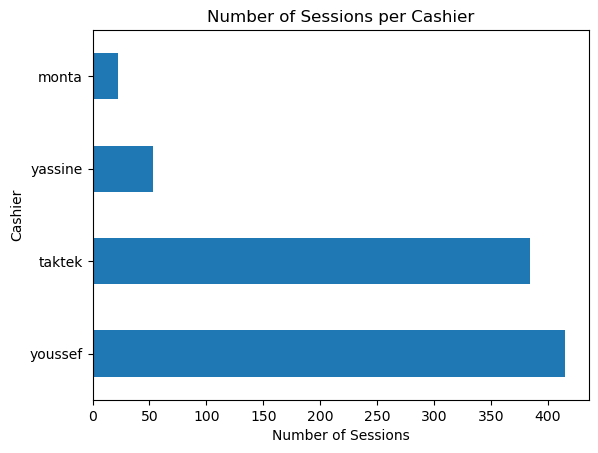

In [29]:
# count how many sessions each cashier handled
df_clean['Cashier'].value_counts().plot(kind='barh')

# add labels so the plot is clearer
plt.xlabel("Number of Sessions")
plt.ylabel("Cashier")
plt.title("Number of Sessions per Cashier")
plt.show()

### Data Observation

During the visualization of sessions per cashier, an unexpected value appeared in the **Cashier** column that contained a timestamp rather than a name. This issue originated from report metadata included in the Excel export. The dataset was cleaned by removing rows where the Cashier column contained timestamp values.

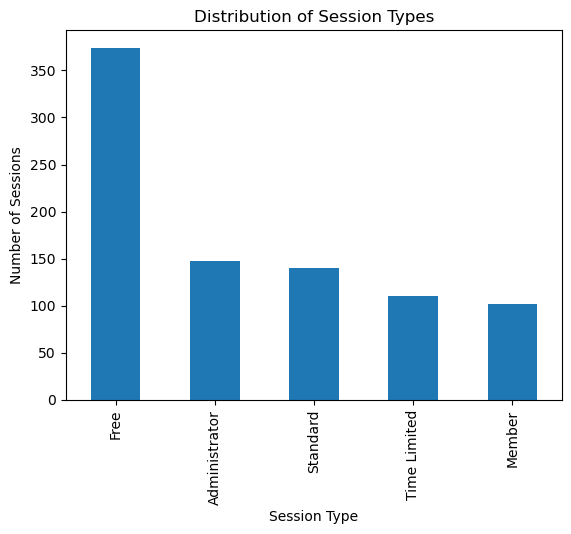

In [30]:
#Visualize Session Type Distribution
# count how many times each session type occurs
df_clean['Session Type'].value_counts().plot(kind='bar')

plt.xlabel("Session Type")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Types")
plt.show()

### Session Type Distribution

The chart shows the frequency of each **session type** in the dataset.  
This helps identify which activities are most commonly performed in the system and how the sessions are distributed across different categories.

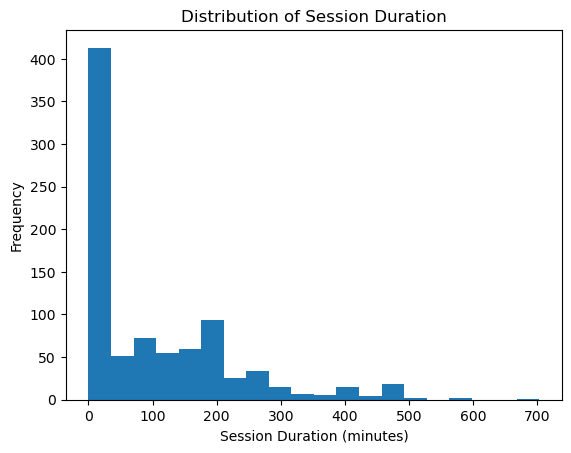

In [31]:
#Analyze Session Duration
# visualize how session durations are distributed
df_clean['Duration_minutes'].plot(kind='hist', bins=20)

plt.xlabel("Session Duration (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Session Duration")
plt.show()

In [32]:
#financial impact per cashier
df_clean.groupby('Cashier')['Total Amount'].sum().plot(kind='barh')

plt.xlabel("Total Session Amount")
plt.ylabel("Cashier")
plt.title("Total Amount Generated by Each Cashier")
plt.show()

TypeError: no numeric data to plot